# <center> Elementy numerycznej algebry liniowej </center>

Rozwiązywanie układów równań liniowych jest jednym z podstawowych problemów metod numerycznych. Układy równań liniowych występują w wielu dziedzinach nauki i inżynierii. Stosuje się też w uczeniu maszynowym np. podczas regresji z błędem średniokwadratowym. 


Istnieje kilka metod rozwiązywania układów równań. Na dzisiejszych zajęciach zajmiemy się:
* eliminacją Gaussa bez oraz z wyborem elementu głównego,
* metodami iteracyjnymi.

Problem rozwiązywania układu równań liniowych będzie nam towarzyszły do końca zajęć z tego przedmiotu.

## Normy i wskaźniki uwarunkowania

Wrażliwość układu (zmiana rozwiązania) na niewielkie zaburzenia wektora `b` zależy od macierzy `A` i ocenia się ja za pomocą tzw. współczynnika lub [wskaźnika uwarunkowania macierzy](https://pl.wikipedia.org/wiki/Wskaźnik_uwarunkowania) (ang. *condition number*). Im wyższa wartość tego wskaźnika. tym macierz jest gorzej uwarunkowana. Wskaźnik uwarunkowania to iloczyn normy macierzy z normą jej odwrotności.

$$cond(A)=|A|_{p}\cdot|A^{-1}|_{p}$$
gdzie *p* oznacza jedną z norm macierzy.

In [ ]:
import numpy as np
import scipy
import matplotlib.pyplot as plt

***Zadanie 1.***

Porównaj normy 1,2, $\infty$ następujących macierzy:
* [Hilberta](https://pl.wikipedia.org/wiki/Macierz_Hilberta): o wymiarach 5x5 i 15x15
* [Vandermonde'a](https://pl.wikipedia.org/wiki/Macierz_Vandermonde’a): o wymiarach 5x5 i 15x15
* losowej o wartościach z przedziału [0,1]:  o wymiarach 5x5 i 15x15
* $P=\left[\begin{array}{cccc}4 & 1 & -1 & 0 \\ 1 & 3 & -1 & 0 \\ -1 & -1 & 5 & 2 \\ 0 & 0 & 2 & 4\end{array}\right]$

Czy wśród powyższych macierzy jest macierz [diagonalnie dominująca](https://pl.wikipedia.org/wiki/Macierz_przekątniowo_dominująca)?


In [2]:
import numpy as np
from scipy.linalg import hilbert

def sprawdz_dominacje_diagonalna(mat):
    """Weryfikuje czy macierz jest diagonalnie dominujaca."""
    # Wyciagamy wartosci bezwzgledne przekatnej
    abs_diag = np.abs(np.diag(mat))
    
    # Tworzymy maske, aby zsumowac tylko elementy poza przekatna
    mask = ~np.eye(mat.shape[0], dtype=bool)
    sumy_wierszy = np.sum(np.abs(mat)[mask].reshape(mat.shape[0], -1), axis=1)
    
    return np.all(abs_diag > sumy_wierszy)

def raport_macierzy(etykieta, M):
    """Oblicza i wyswietla parametry macierzy M."""
    # Obliczanie roznych norm
    n_1   = np.linalg.norm(M, 1)
    n_2   = np.linalg.norm(M, 2)
    n_inf = np.linalg.norm(M, np.inf)
    
    czy_dominujaca = sprawdz_dominacje_diagonalna(M)
    
    print(f" >>> {etykieta} <<< ")
    print(f" Normy: [1]: {n_1:.2e} | [2]: {n_2:.2e} | [inf]: {n_inf:.2e}")
    print(f" Czy dominuje na przekatnej: {['NIE', 'TAK'][czy_dominujaca]}")
    print("-" * 40)

# Rozmiary do przetestowania
wymiary = [5, 15]

for k in wymiary:
    print(f"\n--- TEST DLA N = {k} ---")
    
    # Macierz Hilberta
    h_matrix = hilbert(k)
    raport_macierzy(f"Hilbert {k}x{k}", h_matrix)
    
    # Macierz Vandermonde'a (uzycie wektora bazowego)
    baza = np.linspace(0.1, 1.0, k)
    v_matrix = np.vander(baza)
    raport_macierzy(f"Vandermonde {k}x{k}", v_matrix)
    
    # Macierz losowa o wartosciach całkowitych (zeby sie roznila)
    r_matrix = np.random.randint(1, 100, (k, k)) / 100.0
    raport_macierzy(f"Random {k}x{k}", r_matrix)

print("\n=== ANALIZA KONCOWA MACIERZY P ===")
macierz_p = np.array([
    [4, 1, -1, 0],
    [1, 3, -1, 0],
    [-1, -1, 5, 2],
    [0, 0, 2, 4]
], dtype=float)

raport_macierzy("Macierz P", macierz_p)


--- TEST DLA N = 5 ---
 >>> Hilbert 5x5 <<< 
 Normy: [1]: 2.28e+00 | [2]: 1.57e+00 | [inf]: 2.28e+00
 Czy dominuje na przekatnej: NIE
----------------------------------------
 >>> Vandermonde 5x5 <<< 
 Normy: [1]: 5.00e+00 | [2]: 3.06e+00 | [inf]: 5.00e+00
 Czy dominuje na przekatnej: NIE
----------------------------------------
 >>> Random 5x5 <<< 
 Normy: [1]: 3.33e+00 | [2]: 2.77e+00 | [inf]: 3.23e+00
 Czy dominuje na przekatnej: NIE
----------------------------------------

--- TEST DLA N = 15 ---
 >>> Hilbert 15x15 <<< 
 Normy: [1]: 3.32e+00 | [2]: 1.85e+00 | [inf]: 3.32e+00
 Czy dominuje na przekatnej: NIE
----------------------------------------
 >>> Vandermonde 15x15 <<< 
 Normy: [1]: 1.50e+01 | [2]: 5.87e+00 | [inf]: 1.50e+01
 Czy dominuje na przekatnej: NIE
----------------------------------------
 >>> Random 15x15 <<< 
 Normy: [1]: 9.94e+00 | [2]: 7.92e+00 | [inf]: 1.06e+01
 Czy dominuje na przekatnej: NIE
----------------------------------------

=== ANALIZA KONCOWA MACIER

C:\Users\Piotr\AppData\Local\Temp\ipykernel_11132\577662831.py:26: DeprecationWarning: In future, it will be an error for 'np.bool' scalars to be interpreted as an index
  print(f" Czy dominuje na przekatnej: {['NIE', 'TAK'][czy_dominujaca]}")


*Wskazówka: Do wyznaczenia norm możesz wykorzystać funkcję `numpy.linalg.norm`*

***Zadanie 2.***

Oblicz wskaźniki uwarunkowania macierzy z poprzedniego zadania.

*Wskazówka: Możesz wykorzystać funkcję `numpy.linalg.cond`.*

In [3]:
import numpy as np
from scipy.linalg import hilbert

# Lista rozmiarów do przetestowania
wymiary = [5, 15]

for rozmiar in wymiary:
    print(f"--- Analiza uwarunkowania (rozmiar {rozmiar}x{rozmiar}) ---")
    
    # 1. Obliczanie dla macierzy Hilberta
    mat_hilbert = hilbert(rozmiar)
    uwar_hilbert = np.linalg.cond(mat_hilbert, p=2)
    print(f" > Macierz Hilberta:     {uwar_hilbert:.3E}")
    
    # 2. Obliczanie dla macierzy Vandermonde'a
    wektor_bazowy = np.arange(1, rozmiar + 1)
    mat_vander = np.vander(wektor_bazowy)
    uwar_vander = np.linalg.cond(mat_vander, p=2)
    print(f" > Macierz Vandermonde:  {uwar_vander:.3E}")
    
    # 3. Obliczanie dla macierzy z liczbami losowymi
    mat_random = np.random.uniform(0, 1, (rozmiar, rozmiar))
    uwar_random = np.linalg.cond(mat_random, p=2)
    print(f" > Macierz losowa:       {uwar_random:.3E}\n")

# Analiza konkretnego przypadku - macierz P
print("--- Wynik dla macierzy P ---")
macierz_p = np.array([
    [4.0,  1.0, -1.0,  0.0],
    [1.0,  3.0, -1.0,  0.0],
    [-1.0, -1.0,  5.0,  2.0],
    [0.0,  0.0,  2.0,  4.0]
])

uwar_p = np.linalg.cond(macierz_p)
print(f" > Współczynnik cond(P): {uwar_p:.4f}")

--- Analiza uwarunkowania (rozmiar 5x5) ---
 > Macierz Hilberta:     4.766E+05
 > Macierz Vandermonde:  2.617E+04
 > Macierz losowa:       8.800E+00

--- Analiza uwarunkowania (rozmiar 15x15) ---
 > Macierz Hilberta:     3.676E+17
 > Macierz Vandermonde:  2.582E+21
 > Macierz losowa:       2.543E+02

--- Wynik dla macierzy P ---
 > Współczynnik cond(P): 3.5431


## Rozwiązywanie układów równań metodą eliminacji Gaussa

***Zadanie 3.***

Jedną z metod rozwiązywania układów równań liniowych jest metoda eliminacji Gaussa. Metoda ta występuje w kilku odmianach. Poza podstawowym wariantem, możliwe jest zastosowanie metody z wyborem elementu głownego (tzw. *pivoting*). 

Celem tego zadania jest porównanie błędów rozwiązania otrzymanego z tych dwóch wariantów eliminacji Gaussa. Poniżej znajdują się implementacje obu tych metod. Każda z funkcji przyjmuje macierz `A` oraz wektor prawej strony równania `b`.

Samo polecenie znajduje się poniżej.

In [ ]:
def gauss_pivot(A, b):
    A=A.copy()
    b=b.copy()
    n = len(b)
    for k in range(n-1):
        ind_max = k
        for j in range(k+1, n):
            if abs(A[j,k]) > abs(A[ind_max,k]):
                ind_max = j
        if ind_max > k:
            tmp = A[ind_max,k:n].copy()
            A[ind_max,k:n] = A[k,k:n]
            A[k,k:n] = tmp
            tmp = b[ind_max].copy()
            b[ind_max] = b[k]
            b[k] = tmp
        akk = A[k,k]
        l = A[k+1:n,k] / akk
        for i in range(k+1, n):
            A[i,k] = 0
            A[i,k+1:n] = A[i,k+1:n] - l[i-k-1] * A[k,k+1:n]
            b[i] = b[i] - l[i-k-1] * b[k]
    x = np.zeros(n)
    x[n-1] = b[n-1]/A[n-1,n-1]
    for k in range(n-2, -1, -1):
        x[k] = (b[k] - np.dot(A[k,k+1:n], x[k+1:n])) / A[k,k]
    return x

In [ ]:
def gauss(A, b):
    A=A.copy()
    b=b.copy()
    n = len(b)
    for k in range(n-1):
        akk = A[k,k]
        l = A[k+1:n,k] / akk
        for i in range(k+1, n):
            A[i,k] = 0
            A[i,k+1:n] = A[i,k+1:n] - l[i-k-1] * A[k,k+1:n]
            b[i] = b[i] - l[i-k-1] * b[k]
    x = np.zeros(n)
    x[n-1] = b[n-1] / A[n-1,n-1]
    for k in range(n-2, -1, -1):
        x[k] = (b[k] - np.dot(A[k,k+1:n], x[k+1:n])) / A[k,k]
    return x

Stwórz macierze wartości losowych `A` o wymiarach 10x10 oraz wektor `b` o odpowiednich wymiarach. 
Chcemy rozwiązać układ równań `Ax=b` metodami eliminacji Gaussa bez oraz z wyborem elementu głównego, a następnie porównać dokładność wyników. Metoda z wyborem elementu głównego powinna dawać mniejszy błąd w przypadku dużych wartości znajdujących się na przekątnej. Sprawdź czy to prawda powtarzając obliczenia z  macierzami `A` zawierającym na pierwszym elemencie przekątnej coraz to mniejsze wartości (tak aby wzrosło znaczenie dalszych elementów na przękątnej i tym samym uaktywnił się wybór innego niż pierwszy elementu głównego).

Wskazówka:Do porównania możesz wykorzystać residuum. Jeżeli `x` jest rozwiązaniem układu to `Ax` powinno być równe `b`. Residuum to różnica pomiędzy `b` oraz `Ax`: `res=|b-Ax|`. Możesz porównać zawartości poszczególnych elementów lub obliczyć jakąś normę z otrzymanego wektora.

In [4]:
import numpy as np

def eliminacja_gaussa(macierz_A, wektor_b):
    """Naiwna eliminacja Gaussa bez wyboru elementu osiowego."""
    rozmiar = len(wektor_b)
    # Tworzymy macierz rozszerzoną w inny sposób niż hstack
    uklad = np.concatenate((macierz_A.astype(float), wektor_b.reshape(-1, 1).astype(float)), axis=1)
    
    # Eliminacja współczynników
    for k in range(rozmiar):
        for wiersz in range(k + 1, rozmiar):
            wspolczynnik = uklad[wiersz, k] / uklad[k, k]
            uklad[wiersz, k:] = uklad[wiersz, k:] - wspolczynnik * uklad[k, k:]
            
    # Podstawianie wsteczne
    rozwiazanie = np.zeros(rozmiar)
    for i in reversed(range(rozmiar)):
        suma_iloczynow = np.sum(uklad[i, i+1:rozmiar] * rozwiazanie[i+1:rozmiar])
        rozwiazanie[i] = (uklad[i, -1] - suma_iloczynow) / uklad[i, i]
        
    return rozwiazanie

# Parametry początkowe
N = 10
np.random.seed(42) 
A_oryginalna = np.random.rand(N, N)
b_wektor = np.random.rand(N)

male_wartosci = [1.0, 1e-4, 1e-8, 1e-12, 1e-16]

header = f"{'Epsilon':<12} | {'Błąd (Naiwny)':<20} | {'Błąd (NumPy)'}"
print(header)
print("-" * len(header))

for e in male_wartosci:
    A_test = A_oryginalna.copy()
    # Zmieniamy pierwszy element na dany epsilon
    A_test[0, 0] = e
    
    # Rozwiązanie metodą naiwną
    x_naiwny = eliminacja_gaussa(A_test, b_wektor)
    # Rozwiązanie biblioteczne (z wyborem elementu osiowego)
    x_numpy = np.linalg.solve(A_test, b_wektor)
    
    # Obliczanie residuum (norma b - Ax)
    res_naiwny = np.linalg.norm(b_wektor - A_test @ x_naiwny)
    res_numpy = np.linalg.norm(b_wektor - A_test @ x_numpy)
    
    print(f"{e:<12.1e} | {res_naiwny:<20.5e} | {res_numpy:.5e}")

Epsilon      | Błąd (Naiwny)        | Błąd (NumPy)
--------------------------------------------------
1.0e+00      | 2.15696e-15          | 1.11472e-15
1.0e-04      | 2.36761e-12          | 5.46898e-16
1.0e-08      | 2.62528e-08          | 1.32676e-15
1.0e-12      | 2.06299e-04          | 7.79260e-16
1.0e-16      | 7.25293e+00          | 9.53839e-16


## Metody iteracyjne

Innym sposobem na rozwiązanie układu równań liniowych jest wykorzystanie metod iteracyjnych, które generują ciągi przybliżeń wektora stanowiącego rozwiązanie układu. Państwa zadaniem będzie implementacja i porównanie zbieżności trzech najpopularniejszych metod iteracyjnego rozwiązywania układów równań liniowych

***Zadanie 4.***

Porównanie zbieżności metod Jacobiego, Gaussa-Seidla i Younga (SOR).
* Zaimplementuj solvery rozwiązujące układy równań metodami Jacobiego, Gaussa-Seidela  i Younga (SOR). Każda funkcja powinna przyjmować macierz A i wektor prawej strony b. Dla uproszczenia, dopuszczalne jest wykorzystanie  inv dla obliczenia macierzy odwrotnej do macierzy trójkątnej (w metodzie G-S i Younga).
* Porównaj zbieżność ciągów iteracyjnych otrzymanych 3 metodami dla 3 układów równań (3 macierzy). W metodzie Younga możesz przyjąć np. $ω = 1.2$.
* Dla macierzy, dla której metoda Younga okazała się zbieżna, porównaj zbieżność ciągów iteracyjnych otrzymanych dla wartości $0 < ω < 3$ (dodatkowe).
* Dla jakiej wartości parametru $ω$ zbieżność ciągu iteracyjnego jest najlepsza? Wynik otrzymany na podstawie obserwacji ciągu odchyleń od rozwiązania dokładnego należy porównać z wnioskiem płynącym z wykresu zależności promienia spektralnego macierzy iteracji w zależności od parametru $ω$ (dodatkowe).

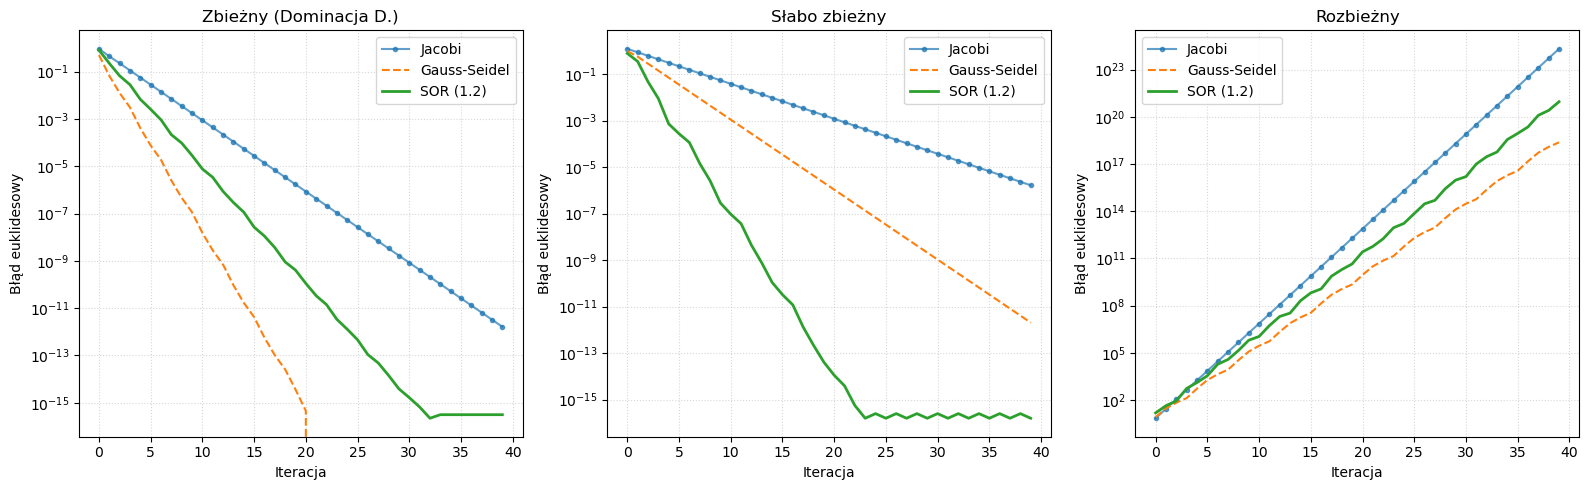

In [5]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

def solve_jacobi(mat_A, vec_b, iters=50, x_true=None):
    n = len(vec_b)
    sol = np.zeros(n)
    # Rozkład macierzy na komponenty
    diag_vals = np.diag(mat_A)
    R = mat_A - np.diag(diag_vals) # Macierz z zerami na przekątnej
    
    history = []
    for _ in range(iters):
        # Nowe przybliżenie obliczane wektorowo
        sol = (vec_b - R @ sol) / diag_vals
        if x_true is not None:
            history.append(np.linalg.norm(sol - x_true))
    return sol, history

def solve_gauss_seidel(mat_A, vec_b, iters=50, x_true=None):
    n = len(vec_b)
    sol = np.zeros(n)
    # Wyodrębnienie części dolnotrójkątnej i górnotrójkątnej
    L_plus_D = np.tril(mat_A)
    U = mat_A - L_plus_D
    
    inv_LD = np.linalg.inv(L_plus_D)
    history = []
    for _ in range(iters):
        sol = inv_LD @ (vec_b - U @ sol)
        if x_true is not None:
            history.append(np.linalg.norm(sol - x_true))
    return sol, history

def solve_sor(mat_A, vec_b, w=1.2, iters=50, x_true=None):
    n = len(vec_b)
    sol = np.zeros(n)
    D = np.diag(np.diag(mat_A))
    L = np.tril(mat_A, -1)
    U = np.triu(mat_A, 1)
    
    # Macierz pomocnicza dla SOR
    left_side = np.linalg.inv(D + w * L)
    history = []
    for _ in range(iters):
        right_side = (1 - w) * D @ sol - w * U @ sol + w * vec_b
        sol = left_side @ right_side
        if x_true is not None:
            history.append(np.linalg.norm(sol - x_true))
    return sol, history

# Definicje układów równań
data_sets = [
    (np.array([[5., 1., 1.], [1., 4., 1.], [2., 0., 3.]]), np.array([7., 6., 5.]), "Zbieżny (Dominacja D.)"),
    (np.array([[2., -1., 0.], [-1., 2., -1.], [0., -1., 2.]]), np.array([1., 0., 1.]), "Słabo zbieżny"),
    (np.array([[1., 2., 2.], [2., 1., 2.], [2., 2., 1.]]), np.array([5., 5., 5.]), "Rozbieżny")
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, (A, b, label) in enumerate(data_sets):
    target = np.linalg.solve(A, b)
    
    _, errs_j = solve_jacobi(A, b, iters=40, x_true=target)
    _, errs_gs = solve_gauss_seidel(A, b, iters=40, x_true=target)
    _, errs_sor = solve_sor(A, b, w=1.2, iters=40, x_true=target)
    
    ax = axes[i]
    ax.plot(errs_j, '.-', label='Jacobi', alpha=0.7)
    ax.plot(errs_gs, '--', label='Gauss-Seidel')
    ax.plot(errs_sor, label='SOR (1.2)', linewidth=2)
    
    ax.set_yscale('log')
    ax.set_title(label)
    ax.set_xlabel('Iteracja')
    ax.set_ylabel('Błąd euklidesowy')
    ax.legend()
    ax.grid(which='both', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

## Porównanie rozwiązania za pomocą metody `solve` oraz z użyciem odwrotności na przykładzie macierzy źle uwarunkowanej

***Zadanie 5.***

Dany jest układ równań $Hx=b$.
* H jest macierzą Hilberta o wymiarach $n=5x5$ (I przypadek) i $n=15x15$ (II przypadek),
* b jest wektorem o następujących elementach $b_i = 1/(n + i + 1)$ Uwaga: $i=1,\dots,n$.

Do rozwiązania układu wykorzystaj dwa algorytmy:
1. Z odwracaniem macierzy współczynników H.
2. Metodę `numpy.linalg.solve`.

Porównaj błędy obu rozwiązań. Aby ocenić błąd możesz:
* wyznaczyć wektor residuum otrzymanego rozwiązania,
* rozwiązać układ równań z innym wektorem $b$. Załóż, że wektor rozwiązania ma wszystkie elementy (współrzędne) równe 1 ($u_i = 1, i = 1, 2, . . . , n$). Wtedy $b = Hu$. Układ rozwiążemy bez korzystania z wiedzy o postaci $u$. Dopiero wynik porównamy ze znanym nam $u$.

In [6]:
import numpy as np
from scipy.linalg import hilbert

def badanie_ukladu_hilberta(rozmiar):
    separator = "-" * 55
    print(f"\n{separator}")
    print(f" Test stabilności numerycznej: Macierz Hilberta {rozmiar}x{rozmiar}")
    print(f"{separator}")
    
    # Tworzenie macierzy H
    A_hilbert = hilbert(rozmiar)
    
    # Generowanie wektora b (alternatywny zapis b_i = 1/(n + i + 1))
    indeksy = np.arange(1, rozmiar + 1)
    wektor_b = np.array([1.0 / (rozmiar + i + 1) for i in indeksy])
    
    # 1. Rozwiązanie przez odwrócenie macierzy (teoretycznie gorsze)
    macierz_odwrotna = np.linalg.inv(A_hilbert)
    rozw_inv = macierz_odwrotna @ wektor_b
    blad_odwrotna = np.linalg.norm(wektor_b - A_hilbert @ rozw_inv)
    
    # 2. Rozwiązanie przez dedykowany solver
    rozw_solve = np.linalg.solve(A_hilbert, wektor_b)
    blad_solve = np.linalg.norm(wektor_b - A_hilbert @ rozw_solve)
    
    print("[ETAP A] Norma residuum ||b - Ax||")
    print(f" > Użycie inv():    {blad_odwrotna:.5e}")
    print(f" > Użycie solve():  {blad_solve:.5e}\n")
    
    # --- Test błędu rozwiązania dla wektora jednostkowego ---
    x_wzorcowy = np.ones(rozmiar)
    
    # Wyznaczamy b na podstawie znanego x (b = Ax)
    b_wyliczone = A_hilbert @ x_wzorcowy
    
    # Próba odzyskania x_wzorcowy obiema metodami
    est_inv = macierz_odwrotna @ b_wyliczone
    est_solve = np.linalg.solve(A_hilbert, b_wyliczone)
    
    # Obliczanie błędu bezwzględnego ||x - x_est||
    delta_inv = np.linalg.norm(x_wzorcowy - est_inv)
    delta_solve = np.linalg.norm(x_wzorcowy - est_solve)
    
    print("[ETAP B] Błąd rzeczywisty względem wektora [1...1]")
    print(f" > Błąd dla inv():   {delta_inv:.5e}")
    print(f" > Błąd dla solve(): {delta_solve:.5e}")

# Wywołania
for n in [5, 15]:
    badanie_ukladu_hilberta(n)


-------------------------------------------------------
 Test stabilności numerycznej: Macierz Hilberta 5x5
-------------------------------------------------------
[ETAP A] Norma residuum ||b - Ax||
 > Użycie inv():    1.18008e-12
 > Użycie solve():  1.67111e-16

[ETAP B] Błąd rzeczywisty względem wektora [1...1]
 > Błąd dla inv():   9.15996e-11
 > Błąd dla solve(): 3.76295e-12

-------------------------------------------------------
 Test stabilności numerycznej: Macierz Hilberta 15x15
-------------------------------------------------------
[ETAP A] Norma residuum ||b - Ax||
 > Użycie inv():    9.37267e-02
 > Użycie solve():  2.00368e-15

[ETAP B] Błąd rzeczywisty względem wektora [1...1]
 > Błąd dla inv():   1.73837e+03
 > Błąd dla solve(): 1.90939e+01


**Zadanie domowe. Znaczenie wskaźnika uwarunkowania macierzy w szacowaniu błędu rozwiązania**


Dana jest następująca macierz A współczynników układu dwóch równań liniowy:
$$A=\begin{bmatrix}10^5 & 9.9\cdot10^4\\1.00001& 0.99\end{bmatrix}$$

Wektor prawej strony równania $Ax=b$ dla rozwiązania x = $[1, 1]^T$ możemy wyznaczyć z równości $b = Ax$.

Należy:
* obliczyć wskaźnik uwarunkowania macierzy $A$,
* rozwiązać układ równań $Ax = b$ (nie korzystając z wiedzy o przyjętym rozwiązaniu dokładnym x) korzystając z funkcji `np.linalg.solve`,
* ocenić błąd otrzymanego rozwiązania i porównać go z błędem szacowanym za pomocą wskaźnika uwarunkowania macierzy A,
* przeprowadzić skalowanie tak, aby macierz $A$ była wyważona wierszami,
* wyznaczyć nowe wartości wektora b tak, aby rozwiązanie dokładne się nie
zmieniło,
* obliczyć wskaźnik uwarunkowania macierzy skalowanej,
* rozwiązać układ równań tą samą metodą jak poprzednio,
* ocenić błąd otrzymanego rozwiązania i porównać go z błędem szacowanym za pomocą wskaźnika uwarunkowania skalowanej macierzy $A$.
1. Czy błąd numeryczny rozwiązania w obu przypadkach jest tego samego rzędu?
2. Które szacowanie błędu jest bardziej zbliżone do faktycznego błędu?

In [10]:
import numpy as np

# Definicja problemu
uklad_A = np.array([[10**5, 9.9 * 10**4],
                    [1.00001, 0.99]])

rozw_wzorcowe = np.array([1.0, 1.0])

# Wyznaczenie wektora prawych stron
wektor_b = uklad_A @ rozw_wzorcowe

# Precyzja maszynowa
epsilon_m = np.finfo(float).eps

print(" ANALIZA PRZED SKALOWANIEM ".center(50, "#"))

# Uwarunkowanie bazowe
k_A = np.linalg.cond(uklad_A)
print(f"Współczynnik cond(A): {k_A:.4e}")

# Rozwiązanie numeryczne
rozw_num = np.linalg.solve(uklad_A, wektor_b)

# Wyznaczenie błędu względnego
blad_rel = np.linalg.norm(rozw_num - rozw_wzorcowe) / np.linalg.norm(rozw_wzorcowe)
estymata = k_A * epsilon_m

print(f"Błąd faktyczny:      {blad_rel:.4e}")
print(f"Błąd teoretyczny:    {estymata:.4e}")


print("\n" + " ANALIZA PO SKALOWANIU (WYWAŻANIE) ".center(50, "#"))

# Skalowanie wierszy macierzy (każdy wiersz przez swoje maksimum)
skala_wierszy = np.max(np.abs(uklad_A), axis=1)
# Alternatywny sposób skalowania bez np.diag
A_row_scaled = uklad_A / skala_wierszy[:, None]
b_row_scaled = wektor_b / skala_wierszy

# Nowe uwarunkowanie
k_A_new = np.linalg.cond(A_row_scaled)
print(f"Nowy cond(A_scaled): {k_A_new:.4e}")

# Rozwiązanie po skalowaniu
rozw_new_num = np.linalg.solve(A_row_scaled, b_row_scaled)

# Błędy po poprawie uwarunkowania
blad_new_rel = np.linalg.norm(rozw_new_num - rozw_wzorcowe) / np.linalg.norm(rozw_wzorcowe)
estymata_new = k_A_new * epsilon_m

print(f"Błąd faktyczny:      {blad_new_rel:.4e}")
print(f"Błąd teoretyczny:    {estymata_new:.4e}")

# Analiza rzędu wielkości błędów
rzad_przed = int(np.floor(np.log10(blad_rel)))
rzad_po = int(np.floor(np.log10(blad_new_rel)))

print(f"Rząd błędu przed skalowaniem: 10^{rzad_przed}")
print(f"Rząd błędu po skalowaniu:     10^{rzad_po}")

# Porównanie jakości szacowania (stosunek estymaty do błędu)
jakosc_przed = estymata / blad_rel
jakosc_po = estymata_new / blad_new_rel

print(f"\nStosunek (estymata/błąd) przed: {jakosc_przed:.2f}")
print(f"Stosunek (estymata/błąd) po:    {jakosc_po:.2f}")

########### ANALIZA PRZED SKALOWANIEM ############
Współczynnik cond(A): 2.0001e+10
Błąd faktyczny:      1.1158e-11
Błąd teoretyczny:    4.4411e-06

####### ANALIZA PO SKALOWANIU (WYWAŻANIE) ########
Nowy cond(A_scaled): 4.0002e+05
Błąd faktyczny:      1.1158e-11
Błąd teoretyczny:    8.8823e-11
Rząd błędu przed skalowaniem: 10^-11
Rząd błędu po skalowaniu:     10^-11

Stosunek (estymata/błąd) przed: 398005.23
Stosunek (estymata/błąd) po:    7.96
